# Figures using new algorithm

In [2]:
# %matplotlib widget
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
import umap

%reload_ext autoreload
%autoreload 2

from tes.data_ingestion import DataRead
from tes.analysis import AnalysisFunc
from tes.algo_umap import UmapAlgo
import numpy as np
import pandas as pd
import statistics
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Patch
import matplotlib.colors as mcolors
from pathlib import Path
import glob

import networkx as nx
import seaborn as sns
from tes.DataUtils import DataUtils
from scipy.stats import mannwhitneyu
from scipy.stats import pearsonr
from scipy.stats import spearmanr
import scipy.stats

In [3]:
analyse = AnalysisFunc()
reader = DataRead()
utils = DataUtils()
algo = UmapAlgo()

../../data/connectivity_matrix/mb_communities.npz already exists
DataUtils initialized


### Figure: Structural measures effect on parameters 
- Take all nodes you have data for

#### Data folders (Containing global order, local order and node community data)
- raw/(BLA,PERI,ENTI, ORBI, RE, PIR)
- raw/check_connector
- raw/check_control

#### Data folders (containing global order and local order)
- raw/random (contains betweeness centrality data)
- raw/random_nodes
- results/processed (only global order is correct for 1000 iterations)

# Compute data for figure 3
- Read data of all the nodes from respective folders
- Find betweenness centrality, degree, nodal efficiency and eigen vector centrality for above nodes

### All the nodes for which we have to compute 

In [4]:
control_node = [251, 38, 71, 284, 1, 214, 149, 362]
control_name = ["MOB", "LSc", "MOp", "MRN"]
connector_node = [214, 1, 215, 2, 249, 36, 137, 350, 53, 266]
connector_name = ["MOp", "MOs", "PERI", "LHA", "ENTI"]
imp_nodes = [36, 249, 53, 266, 23, 236, 113, 326, 64, 277, 43, 256]
imp_name = ["PERI", "ENTI", "ORB", "RE", "BLA", "PIR"]

nodes = [
    36,
    249,
    53,
    266,
    23,
    236,
    113,
    326,
    64,
    277,
    43,
    256,
    214,
    1,
    215,
    2,
    137,
    350,
    251,
    38,
    71,
    284,
    149,
    362,
]
node_label = [
    "PERI",
    "ENTI",
    "ORB",
    "RE",
    "BLA",
    "PIR",
    "MOp",
    "MOs",
    "LHA",
    "MOB",
    "LSc",
    "MRN",
    "FN",
]

#### Calculate 
- Betweenness centrality
- Nodal Efficiency
- Degree
- Eigen vector centrality

In [5]:
G = nx.from_numpy_array(utils.WHOLE_BRAIN_CONN)
bet_cent = nx.betweenness_centrality(G)
deg_cent = nx.degree_centrality(G)
eig_cent = nx.eigenvector_centrality(G)
efficiency = {}
for node in G.nodes:
    # Calculate the sum of reciprocal of shortest path lengths from the node to all other nodes
    sp_lengths = nx.shortest_path_length(G, source=node)
    sum_reciprocal_sp = sum(1 / length for length in sp_lengths.values() if length > 0)

    # Calculate efficiency: E(v) = (1 / (N-1)) * sum(1 / d(v, u))
    # where N is the number of nodes and d(v, u) is the shortest path length between v and u
    efficiency[node] = sum_reciprocal_sp / (len(G.nodes) - 1)


bc_vals = []
deg_vals = []
ev_vals = []
ne_vals = []

for i in nodes:
    bc_vals.append(bet_cent[i])
    deg_vals.append(deg_cent[i])
    ev_vals.append(eig_cent[i])
    ne_vals.append(efficiency[i])

print(f"Betweenness centrality values: {bc_vals}")
print(f"Degree centrality values: {deg_vals}")
print(f"Eigen vector centrality values: {ev_vals}")
print(f"Nodal Efficiency values: {ne_vals}")

Betweenness centrality values: [0.018279655930717145, 0.018279655930717127, 0.015142250584322597, 0.015142250584322609, 0.0006490876667139932, 0.0006490876667139933, 0.01006672083950362, 0.010066720839503631, 0.0035324020639247587, 0.0035324020639247566, 0.001820790434177627, 0.0018207904341776264, 0.024213330492729394, 0.024213330492729373, 0.020510702767149596, 0.020510702767149613, 0.021876077588668236, 0.021876077588668195, 5.380812051561027e-06, 5.380812051561027e-06, 3.1673671682144285e-05, 3.1673671682144285e-05, 0.008944551377672819, 0.008944551377672819]
Degree centrality values: [0.27999999999999997, 0.27999999999999997, 0.2564705882352941, 0.2564705882352941, 0.09411764705882353, 0.09411764705882353, 0.21411764705882352, 0.21411764705882352, 0.16941176470588235, 0.16941176470588235, 0.10352941176470587, 0.10352941176470587, 0.3364705882352941, 0.3364705882352941, 0.3035294117647059, 0.3035294117647059, 0.30117647058823527, 0.30117647058823527, 0.018823529411764704, 0.0188235

## Calculate 
- Number of transitions
- Transition time
- Coverage

#### Read data of important nodes

- In PIR removed network, iteration 36 shows coverage of NaN in first transition as can be seen in plot. Removing iterations with 0 coverage or NaN value

In [5]:
## Getting PIR data to check for coverage
df_pir = reader.data_read_bz2("raw/PIR/itr_200.bz2")
p = algo.compute_param_df(df_pir)

/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainab

start [28800]
start [11700]


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainab

start [25600]
26211
start [27300]


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

7119


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainab

start [11000]
12262
start [8200, 13100]


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


KeyboardInterrupt: 

In [6]:
p["cov"].index(np.nan)

36

/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainab

start [12800, 13300, 13900, 14500, 18700, 23300, 30200, 32300, 38600]


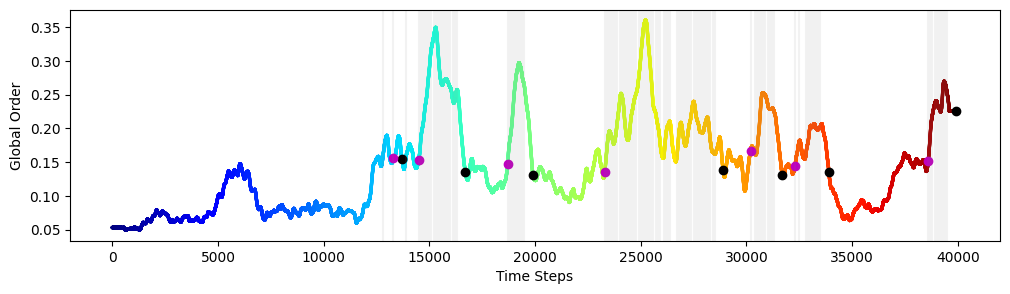

In [7]:
l = algo.compute_parameters(df_pir[36])
algo.plot_transition(df_pir[36], l["start_points"], l["stop_points"])

In [75]:
l["stop_points"]
cv = algo.compute_coverage(df_pir[36], l["start_points"], l["stop_points"])

cv

nan

In [81]:
l["start_points"]

[13300, 14500, 18700, 23300, 30200, 32300, 38600]

In [77]:
l["stop_points"]

[13300, 16300, 19500, 28500, 31300, 33500, 39500]

# Calculating for all data

In [25]:
# read data of NOI
FN_folder = Path("../../data/raw/FN/")
ENTI_folder = Path("../../data/raw/ENTI/")
ORBI_folder = Path("../../data/raw/ORBI/")
PERI_folder = Path("../../data/raw/PERI/")
PIR_folder = Path("../../data/raw/PIR/")
RE_folder = Path("../../data/raw/RE/")
BLA_folder = Path("../../data/raw/BLA/")
files_nc = []
files_itr = []
folders = [PERI_folder, ENTI_folder, ORBI_folder, RE_folder, BLA_folder, PIR_folder]
for folder in folders:
    file_nc = glob.glob(str(folder / "nc_200.bz2"))
    files_nc.append(file_nc[0])
    file_itr = glob.glob(str(folder / "itr_200.bz2"))
    files_itr.append(file_itr[0])

# read data of connector nodes
data_folder = Path("../../data/raw/check_connector/")
connector_nc = glob.glob(str(data_folder / "nc_200*.bz2"))
connector_itr = glob.glob(str(data_folder / "itr_200*.bz2"))

# remove repeated nodes
connector_nc.pop(2)
connector_nc.pop(3)
connector_itr.pop(2)
connector_itr.pop(3)
connector_itr.pop(-1)

files_nc = files_nc + connector_nc
files_itr = files_itr + connector_itr

# print(files_nc)
# print(files_itr)

# read data of control nodes
data_folder = Path("../../data/raw/check_control/")
control_nc = glob.glob(str(data_folder / "nc_200*.bz2"))
control_itr = glob.glob(str(data_folder / "itr_200*.bz2"))

# remove repeated nodes
control_nc.pop(2)
control_itr.pop(2)
control_itr.pop(-1)

files_nc = files_nc + control_nc
files_itr = files_itr + control_itr


# above file sequence arranged in order of node label
# print(files_nc)
# print(files_itr)

trans_count = []
trans_time = []
sync_time = []
fp_time = []
coverage = []
for f_nc, f_itr in zip(files_nc, files_itr):
    # df_nc = pd.read_pickle(f_nc, compression="bz2")
    df_itr = pd.read_pickle(f_itr, compression="bz2")

    # Calculating transition time and number of transitions
    params = algo.compute_param_df(df_itr)

    trans_count.append(params["tran_per"][-1])

    trans_time.append(statistics.median(params["trans"]))

    sync = [i for i in params["sync"] if i != 0]
    sync_time.append(statistics.median(sync))

    fp_time.append(statistics.median(params["fpt"]))

    cvr = [j for j in params["cov"] if j != 0 and not np.isnan(j)]
    coverage.append(statistics.median(cvr))


print(trans_count)
print(trans_time)
print(sync_time)
print(fp_time)
print(coverage)

/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainab

start [17600]
18800


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainab

start [7000]
8642
start [20500]


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

15904


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainab

start [35600]
start [7600]


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


8620
[126, 247, 275, 275, 152, 210, 237, 235, 196, 204, 275, 249]
[64.875, 55.475, 58.175, 57.45, 64.9, 57.7, 57.300000000000004, 56.400000000000006, 53.300000000000004, 63.900000000000006, 60.800000000000004, 60.7]
[87.5, 90.0, 116.83333333333334, 93.57142857142857, 99.6875, 101.25, 87.5, 125.16666666666666, 90.0, 101.66666666666667, 110.13888888888889, 111.25]
[710.0, 647.5, 615.0, 555.0, 605.0, 605.0, 607.5, 580.0, 610.0, 560.0, 595.0, 557.5]
[0.4339410213069944, 0.2837616191434674, 0.3950470928444737, 0.39734734526850146, 0.42041081182446527, 0.3421174773037126, 0.35432649710422204, 0.33070115025231417, 0.3300233898921181, 0.38836284641224394, 0.4128091836397204, 0.3560508099126047]


## Save above data 

It took about half an hour


In [26]:
keys = ["trans_count", "trans_time", "sync_time", "fp_time", "coverage"]
values = [trans_count, trans_time, sync_time, fp_time, coverage]

res_dict = dict(zip(keys, values))
# reader.data_dump_pkl('results/algo_res.pkl',res_dict)

## Read data from pkl file


In [6]:
parameter = reader.data_read_pkl("results/algo_res.pkl")
trans_count = parameter["trans_count"]
trans_time = parameter["trans_time"]
sync_time = parameter["sync_time"]
fp_time = parameter["fp_time"]
coverage = parameter["coverage"]

## Compile data in dataframe

Adding parameters for FN as I forgot to append to above at last

In [7]:
# df_fn = reader.data_read_bz2('raw/FN/itr_200.bz2')
# params = algo.compute_param_df(df_fn)
# reader.data_dump_pkl('results/fn_new_algo_res.pkl',params)
## saved fn data in pkl file so that you don't have to run code again and again


params = reader.data_read_pkl("results/fn_new_algo_res.pkl")
trans_count.append(params["tran_per"][-1])

trans_time.append(statistics.median(params["trans"]))

# sync = 0 for iterations which have single transitions or no transitions that's why removing them
sync = [i for i in params["sync"] if i != 0]
sync_time.append(statistics.median(sync))

fp_time.append(statistics.median(params["fpt"]))

cvr = [j for j in params["cov"] if j != 0 and not np.isnan(j)]
coverage.append(statistics.median(cvr))

In [8]:
# removing duplicate data from centrality values so that length matches
def dup_cent_rem(cent):
    j = 0
    val = []
    while j < len(cent):
        val.append(cent[j])
        j += 2

    return val


# z scoring all values
b_d = dup_cent_rem(bc_vals)
b = [(x - np.mean(b_d)) / np.std(b_d) for x in b_d]
b.append(0)

n_d = dup_cent_rem(ne_vals)
n = [(x - np.mean(n_d)) / np.std(n_d) for x in n_d]
n.append(0)

d_d = dup_cent_rem(deg_vals)
d = [(x - np.mean(d_d)) / np.std(d_d) for x in d_d]
d.append(0)

e_d = dup_cent_rem(ev_vals)
e = [(x - np.mean(e_d)) / np.std(e_d) for x in e_d]
e.append(0)

df = pd.DataFrame(
    {
        "NODES": node_label,
        "TRANS_COUNT": trans_count,
        "TRANS_TIME": trans_time,
        "FP_TIME": fp_time,
        "SYNC_TIME": sync_time,
        "COVERAGE": coverage,
        "BET_CENT": b,
        "NOD_EFF": n,
        "DEG_CENT": d,
        "EIG_CENT": e,
    }
)

print(df)

   NODES  TRANS_COUNT  TRANS_TIME  FP_TIME   SYNC_TIME  COVERAGE  BET_CENT  \
0   PERI          126      64.875    710.0   87.500000  0.433941  0.886346   
1   ENTI          247      55.475    647.5   90.000000  0.283762  0.532414   
2    ORB          275      58.175    615.0  116.833333  0.395047 -1.102570   
3     RE          275      57.450    555.0   93.571429  0.397347 -0.040160   
4    BLA          152      64.900    605.0   99.687500  0.420411 -0.777301   
5    PIR          210      57.700    605.0  101.250000  0.342117 -0.970389   
6    MOp          237      57.300    607.5   87.500000  0.354326  1.555728   
7    MOs          235      56.400    580.0  125.166667  0.330701  1.138032   
8    LHA          196      53.300    610.0   90.000000  0.330023  1.292061   
9    MOB          204      63.900    560.0  101.666667  0.388363 -1.175187   
10   LSc          275      60.800    595.0  110.138889  0.412809 -1.172221   
11   MRN          249      60.700    557.5  111.250000  0.356051

#### Normalising centrality values so that they are on same scale

In [43]:
# df['BET_CENT']=(df['BET_CENT']-df['BET_CENT'].mean())/df['BET_CENT'].std()
# df['DEG_CENT']=(df['DEG_CENT']-df['DEG_CENT'].mean())/df['DEG_CENT'].std()
# df['NOD_EFF']=(df['NOD_EFF']-df['NOD_EFF'].mean())/df['NOD_EFF'].std()
# df['EIG_CENT']=(df['EIG_CENT']-df['EIG_CENT'].mean())/df['EIG_CENT'].std()

### Sorting values in ascending order wrt various 

In [10]:
df_bc = df.sort_values("BET_CENT", ascending=True, inplace=False)
df_ne = df.sort_values("NOD_EFF", ascending=True, inplace=False)
df_de = df.sort_values("DEG_CENT", ascending=True, inplace=False)
df_ee = df.sort_values("EIG_CENT", ascending=True, inplace=False)

In [11]:
df

,NODES,TRANS_COUNT,TRANS_TIME,FP_TIME,SYNC_TIME,COVERAGE,BET_CENT,NOD_EFF,DEG_CENT,EIG_CENT
0,PERI,126,64.875,710.0,87.500000,0.433941,0.886346,0.709872,0.793680,0.590284
1,ENTI,247,55.475,647.5,90.000000,0.283762,0.532414,0.461508,0.574229,0.042929
2,ORB,275,58.175,615.0,116.833333,0.395047,-1.102570,-0.545022,-0.939980,-0.734136
3,RE,275,57.450,555.0,93.571429,0.397347,-0.040160,0.356933,0.179218,0.247571
4,BLA,152,64.900,605.0,99.687500,0.420411,-0.777301,-0.048293,-0.237738,-0.361159
5,PIR,210,57.700,605.0,101.250000,0.342117,-0.970389,-0.558094,-0.852200,-0.942192
6,MOp,237,57.300,607.5,87.500000,0.354326,1.555728,1.032311,1.320362,1.208568
7,MOs,235,56.400,580.0,125.166667,0.330701,1.138032,0.919021,1.013131,1.201774
8,LHA,196,53.300,610.0,90.000000,0.330023,1.292061,0.919021,0.991186,1.104563
9,MOB,204,63.900,560.0,101.666667,0.388363,-1.175187,-2.189893,-1.642223,-1.648583


### Removing FN row

In [12]:
a = df_bc.loc[12]
df_bc.drop(12, inplace=True)
df_bc

,NODES,TRANS_COUNT,TRANS_TIME,FP_TIME,SYNC_TIME,COVERAGE,BET_CENT,NOD_EFF,DEG_CENT,EIG_CENT
9,MOB,204,63.900,560.0,101.666667,0.388363,-1.175187,-2.189893,-1.642223,-1.648583
10,LSc,275,60.800,595.0,110.138889,0.412809,-1.172221,-1.632162,-1.642223,-1.566574
2,ORB,275,58.175,615.0,116.833333,0.395047,-1.102570,-0.545022,-0.939980,-0.734136
5,PIR,210,57.700,605.0,101.250000,0.342117,-0.970389,-0.558094,-0.852200,-0.942192
4,BLA,152,64.900,605.0,99.687500,0.420411,-0.777301,-0.048293,-0.237738,-0.361159
11,MRN,249,60.700,557.5,111.250000,0.356051,-0.166753,0.574797,0.442559,0.856955
3,RE,275,57.450,555.0,93.571429,0.397347,-0.040160,0.356933,0.179218,0.247571
1,ENTI,247,55.475,647.5,90.000000,0.283762,0.532414,0.461508,0.574229,0.042929
0,PERI,126,64.875,710.0,87.500000,0.433941,0.886346,0.709872,0.793680,0.590284
7,MOs,235,56.400,580.0,125.166667,0.330701,1.138032,0.919021,1.013131,1.201774


## Adding FN row at last

In [13]:
df_bc.loc[12] = a
df_bc_true = df_bc
df_bc_true

,NODES,TRANS_COUNT,TRANS_TIME,FP_TIME,SYNC_TIME,COVERAGE,BET_CENT,NOD_EFF,DEG_CENT,EIG_CENT
9,MOB,204,63.900,560.0,101.666667,0.388363,-1.175187,-2.189893,-1.642223,-1.648583
10,LSc,275,60.800,595.0,110.138889,0.412809,-1.172221,-1.632162,-1.642223,-1.566574
2,ORB,275,58.175,615.0,116.833333,0.395047,-1.102570,-0.545022,-0.939980,-0.734136
5,PIR,210,57.700,605.0,101.250000,0.342117,-0.970389,-0.558094,-0.852200,-0.942192
4,BLA,152,64.900,605.0,99.687500,0.420411,-0.777301,-0.048293,-0.237738,-0.361159
11,MRN,249,60.700,557.5,111.250000,0.356051,-0.166753,0.574797,0.442559,0.856955
3,RE,275,57.450,555.0,93.571429,0.397347,-0.040160,0.356933,0.179218,0.247571
1,ENTI,247,55.475,647.5,90.000000,0.283762,0.532414,0.461508,0.574229,0.042929
0,PERI,126,64.875,710.0,87.500000,0.433941,0.886346,0.709872,0.793680,0.590284
7,MOs,235,56.400,580.0,125.166667,0.330701,1.138032,0.919021,1.013131,1.201774


In [14]:
df_bc_true = pd.concat([df_bc_true.loc[[12]], df_bc_true.drop(12)])

In [15]:
df_bc_true

,NODES,TRANS_COUNT,TRANS_TIME,FP_TIME,SYNC_TIME,COVERAGE,BET_CENT,NOD_EFF,DEG_CENT,EIG_CENT
12,FN,299,59.900,570.0,111.666667,0.376182,0.000000,0.000000,0.000000,0.000000
9,MOB,204,63.900,560.0,101.666667,0.388363,-1.175187,-2.189893,-1.642223,-1.648583
10,LSc,275,60.800,595.0,110.138889,0.412809,-1.172221,-1.632162,-1.642223,-1.566574
2,ORB,275,58.175,615.0,116.833333,0.395047,-1.102570,-0.545022,-0.939980,-0.734136
5,PIR,210,57.700,605.0,101.250000,0.342117,-0.970389,-0.558094,-0.852200,-0.942192
4,BLA,152,64.900,605.0,99.687500,0.420411,-0.777301,-0.048293,-0.237738,-0.361159
11,MRN,249,60.700,557.5,111.250000,0.356051,-0.166753,0.574797,0.442559,0.856955
3,RE,275,57.450,555.0,93.571429,0.397347,-0.040160,0.356933,0.179218,0.247571
1,ENTI,247,55.475,647.5,90.000000,0.283762,0.532414,0.461508,0.574229,0.042929
0,PERI,126,64.875,710.0,87.500000,0.433941,0.886346,0.709872,0.793680,0.590284


## Final Plot - Fig 2
- Arranged parameter data in order of their betweenness centrality degree
- scatter plot between betweenness centrality and each parameter

In [1]:
f, ((ax1, ax01), (ax2, ax02), (ax3, ax03), (ax4, ax04), (ax5, ax05)) = plt.subplots(
    5, 2, figsize=(16, 22), sharex=False
)
df_bc = df_bc_true
ax1.set_title("Hypothesis parameters vs Centrality values")
ax1.bar(df_bc["NODES"], df_bc["TRANS_COUNT"], color=cm.Greys(0.3))
ax1.set_ylabel("Number of transitions")
# drop FN row so that it doesn't mess up with centrality values
df_bc = df_bc.drop(12)
ax1_2 = ax1.twinx()
ax1_2.plot(df_bc["NODES"], df_bc["BET_CENT"], "r", label="betweenness centrality")
ax1_2.plot(df_bc["NODES"], df_bc["NOD_EFF"], "c", label="nodal efficiency")
ax1_2.plot(df_bc["NODES"], df_bc["DEG_CENT"], "m", label="degree centrality")
ax1_2.plot(df_bc["NODES"], df_bc["EIG_CENT"], "g", label="eigen vector centrality")


ax01.scatter(df_bc["BET_CENT"], df_bc["TRANS_COUNT"])
corr, p_val = pearsonr(df_bc["BET_CENT"], df_bc["TRANS_COUNT"])
corr, p_val = spearmanr(df_bc["BET_CENT"], df_bc["TRANS_COUNT"])
print(
    f"The correlation between bet_cent and transition count is {corr} with p_val {p_val}"
)
ax01.text(
    0.05,
    0.1,  # relative position in axes coordinates
    f"corr={corr:.3g}, p = {p_val:.3g}",
    transform=ax01.transAxes,  # so coords are relative to axes (0–1)
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7),
)
ax01.set_title("Parameters vs Betweenness Centrality Values ")

# restore df_bc with FN data
df_bc = df_bc_true
ax2.bar(df_bc["NODES"], df_bc["TRANS_TIME"], color=cm.Greys(0.3))
ax2.set_ylabel("Transition Time")
# drop FN row
df_bc = df_bc.drop(12)
ax2_2 = ax2.twinx()
ax2_2.plot(df_bc["NODES"], df_bc["BET_CENT"], "r", label="betweenness centrality")
ax2_2.plot(df_bc["NODES"], df_bc["NOD_EFF"], "c", label="nodal efficiency")
ax2_2.plot(df_bc["NODES"], df_bc["DEG_CENT"], "m", label="degree centrality")
ax2_2.plot(df_bc["NODES"], df_bc["EIG_CENT"], "g", label="eigen vector centrality")
ax02.scatter(df_bc["BET_CENT"], df_bc["TRANS_TIME"])
corr, p_val = pearsonr(df_bc["BET_CENT"], df_bc["TRANS_TIME"])
corr, p_val = spearmanr(df_bc["BET_CENT"], df_bc["TRANS_TIME"])
ax02.text(
    0.05,
    0.1,  # relative position in axes coordinates
    f"corr={corr:.3g}, p = {p_val:.3g}",
    transform=ax02.transAxes,  # so coords are relative to axes (0–1)
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7),
)
print(
    f"The correlation between bet_cent and transition time is {corr} with p_val {p_val}"
)

df_bc = df_bc_true
ax3.bar(df_bc["NODES"], df_bc["COVERAGE"], color=cm.Greys(0.3))
ax3.set_ylabel("Coverage")
# drop FN row
df_bc = df_bc.drop(12)
ax3_2 = ax3.twinx()
ax3_2.plot(df_bc["NODES"], df_bc["BET_CENT"], "r", label="betweenness centrality")
ax3_2.plot(df_bc["NODES"], df_bc["NOD_EFF"], "c", label="nodal efficiency")
ax3_2.plot(df_bc["NODES"], df_bc["DEG_CENT"], "m", label="degree centrality")
ax3_2.plot(df_bc["NODES"], df_bc["EIG_CENT"], "g", label="eigen vector centrality")
ax3_2.set_ylabel("Normalised Centrality Values")
ax03.scatter(df_bc["BET_CENT"], df_bc["COVERAGE"])
corr, p_val = pearsonr(df_bc["BET_CENT"], df_bc["COVERAGE"])
corr, p_val = spearmanr(df_bc["BET_CENT"], df_bc["COVERAGE"])
ax03.text(
    0.05,
    0.1,  # relative position in axes coordinates
    f"corr={corr:.3g}, p = {p_val:.3g}",
    transform=ax03.transAxes,  # so coords are relative to axes (0–1)
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7),
)
print(f"The correlation between bet_cent and coverage is {corr} with p_val {p_val}")

df_bc = df_bc_true
ax4.bar(df_bc["NODES"], df_bc["SYNC_TIME"], color=cm.Greys(0.3))
ax4.set_ylabel("TSync Time")
# drop FN row
df_bc = df_bc.drop(12)
ax4_2 = ax4.twinx()
ax4_2.plot(df_bc["NODES"], df_bc["BET_CENT"], "r", label="betweenness centrality")
ax4_2.plot(df_bc["NODES"], df_bc["NOD_EFF"], "c", label="nodal efficiency")
ax4_2.plot(df_bc["NODES"], df_bc["DEG_CENT"], "m", label="degree centrality")
ax4_2.plot(df_bc["NODES"], df_bc["EIG_CENT"], "g", label="eigen vector centrality")
ax04.scatter(df_bc["BET_CENT"], df_bc["SYNC_TIME"])
corr, p_val = pearsonr(df_bc["BET_CENT"], df_bc["SYNC_TIME"])
corr, p_val = spearmanr(df_bc["BET_CENT"], df_bc["SYNC_TIME"])
ax04.text(
    0.05,
    0.1,  # relative position in axes coordinates
    f"corr={corr:.3g}, p = {p_val:.3g}",
    transform=ax04.transAxes,  # so coords are relative to axes (0–1)
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7),
)
print(f"The correlation between bet_cent and sync time is {corr} with p_val {p_val}")


df_bc = df_bc_true
ax5.bar(df_bc["NODES"], df_bc["FP_TIME"], color=cm.Greys(0.3))
ax5.set_ylabel("First passage time")
# drop FN row
df_bc = df_bc.drop(12)
ax5_2 = ax5.twinx()
ax5_2.plot(df_bc["NODES"], df_bc["BET_CENT"], "r", label="betweenness centrality")
ax5_2.plot(df_bc["NODES"], df_bc["NOD_EFF"], "c", label="nodal efficiency")
ax5_2.plot(df_bc["NODES"], df_bc["DEG_CENT"], "m", label="degree centrality")
ax5_2.plot(df_bc["NODES"], df_bc["EIG_CENT"], "g", label="eigen vector centrality")
ax5.set_xlabel("Nodes")


ax05.scatter(df_bc["BET_CENT"], df_bc["FP_TIME"])
ax05.set_xlabel("Betweenness centrality")
corr, p_val = pearsonr(df_bc["BET_CENT"], df_bc["FP_TIME"])
corr, p_val = spearmanr(df_bc["BET_CENT"], df_bc["FP_TIME"])
ax05.text(
    0.05,
    0.1,  # relative position in axes coordinates
    f"corr={corr:.3g}, p = {p_val:.3g}",
    transform=ax05.transAxes,  # so coords are relative to axes (0–1)
    fontsize=12,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.7),
)
print(
    f"The correlation between bet_cent and first passage time is {corr} with p_val {p_val}"
)

lines, labels = ax1_2.get_legend_handles_labels()
f.legend(
    lines, labels, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 0.93)
)
f.subplots_adjust(bottom=0.15)  # increase bottom margin

# f.tight_layout()
# f.savefig('fig_2.png')
# plt.subplots_adjust(bottom=0.04)

NameError: name 'plt' is not defined

# Functional Metrics - Figure 4

- Plot on median time spent vs degree plot
- Dark grey for data nodes
- Light grey for non data nodes

#### Getting  median time spent and degree values for all nodes

In [40]:
df_nc = reader.data_read_bz2("raw/FN/nc_200.bz2")
df_itr = reader.data_read_bz2("raw/FN/itr_200.bz2")
# here G is the undirected graph
G = nx.from_numpy_array(utils.WHOLE_BRAIN_CONN)
df_r = df_nc.reset_index(drop=True)


i = 0
f = 5000
time_list = []
node_list = []
while f < df_r.shape[0]:
    l = analyse.compute_time_spent_mc(df_r.iloc[i:f, :])
    node_list.append(l)
    i = f
    f += 5000

df_time_spent = pd.DataFrame(node_list)
df_time_spent.shape

# calculate median of every column
MTS = df_time_spent.median()
med_time_spent = list(MTS)
keys = list(range(0, 426))
mts_dict = dict(zip(keys, med_time_spent))
mts_sorted = dict(sorted(mts_dict.items(), key=lambda item: item[1]))

degree = nx.degree_centrality(G)
degree_val = list(degree.values())

#### Getting MTS values for our nodes

In [41]:
mts_vals = []
nodes_half = [36, 53, 23, 113, 64, 43, 1, 215, 137, 38, 71, 149]
for i in nodes_half:
    mts_vals.append(mts_dict[i])
print(mts_vals)

[1657.0, 1582.0, 1696.0, 1577.0, 1711.0, 1716.0, 436.0, 1368.0, 961.0, 1880.0, 1560.0, 257.0]


## Final plot - Figure 3

In [42]:
df.columns

Index(['NODES', 'TRANS_COUNT', 'TRANS_TIME', 'FP_TIME', 'SYNC_TIME',
       'COVERAGE', 'BET_CENT', 'NOD_EFF', 'DEG_CENT', 'EIG_CENT'],
      dtype='object')

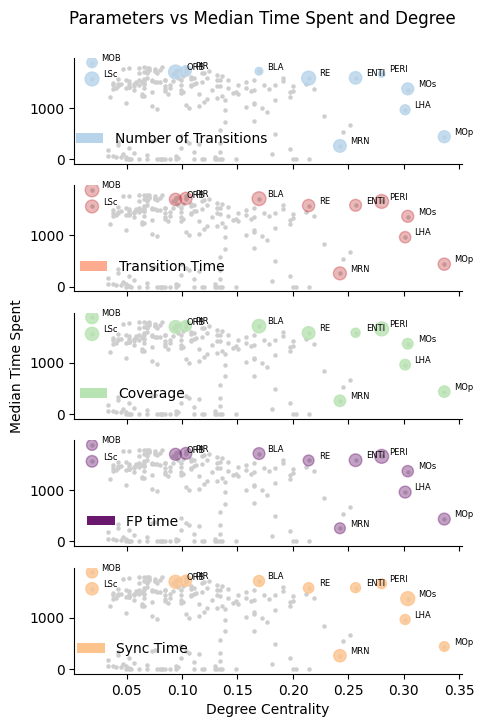

In [65]:
f, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(5, 1, figsize=(5, 8), sharex=True)

f.suptitle("Parameters vs Median Time Spent and Degree", x=0.5, y=0.94)
ax1.scatter(degree_val[0:213], med_time_spent[0:213], s=5, color=cm.Greys(0.3))
max = df["TRANS_COUNT"].max()
ax1.scatter(
    d,
    mts_vals,
    s=df["TRANS_COUNT"].apply(lambda x: ((10 * x / max)) ** 2),
    color=cm.Blues(0.3),
    alpha=0.8,
)
ax1.spines[["right", "top"]].set_visible(False)
k = 0
for x, y, s in zip(d, mts_vals, df["TRANS_COUNT"]):

    r = np.sqrt(s)
    dx = dy = 0.05 * r / 86
    ax1.annotate(
        node_label[k],
        xy=(x, y),
        xytext=(x + dx, y + dy),
        textcoords="data",
        ha="left",
        va="bottom",
        fontsize=6,
        color="black",
    )
    k += 1


ax2.scatter(degree_val[0:213], med_time_spent[0:213], s=5, color=cm.Greys(0.3))
max = df["TRANS_TIME"].max()
ax2.scatter(
    d,
    mts_vals,
    s=df["TRANS_TIME"].apply(lambda x: ((10 * x / max)) ** 2),
    color=cm.Reds(0.8),
    alpha=0.3,
)
ax2.spines[["right", "top"]].set_visible(False)
k = 0
for x, y, s in zip(d, mts_vals, df["TRANS_COUNT"]):

    r = np.sqrt(s)
    dx = dy = 0.05 * r / 86
    ax2.annotate(
        node_label[k],
        xy=(x, y),
        xytext=(x + dx, y + dy),
        textcoords="data",
        ha="left",
        va="bottom",
        fontsize=6,
        color="black",
    )
    k += 1


ax3.scatter(degree_val[0:213], med_time_spent[0:213], s=5, color=cm.Greys(0.3))
max = df["COVERAGE"].max()
ax3.scatter(
    d,
    mts_vals,
    s=df["COVERAGE"].apply(lambda x: ((10 * x / max)) ** 2),
    color=cm.Greens(0.3),
    alpha=0.8,
)
ax3.spines[["right", "top"]].set_visible(False)
k = 0
for x, y, s in zip(d, mts_vals, df["TRANS_COUNT"]):

    r = np.sqrt(s)
    dx = dy = 0.05 * r / 86
    ax3.annotate(
        node_label[k],
        xy=(x, y),
        xytext=(x + dx, y + dy),
        textcoords="data",
        ha="left",
        va="bottom",
        fontsize=6,
        color="black",
    )
    k += 1
ax3.set_ylabel("Median Time Spent")


ax4.scatter(degree_val[0:213], med_time_spent[0:213], s=5, color=cm.Greys(0.3))
max = df["FP_TIME"].max()
ax4.scatter(
    d,
    mts_vals,
    s=df["FP_TIME"].apply(lambda x: ((10 * x / max)) ** 2),
    color=cm.inferno(0.3),
    alpha=0.4,
)
ax4.spines[["right", "top"]].set_visible(False)
k = 0
for x, y, s in zip(d, mts_vals, df["TRANS_COUNT"]):

    r = np.sqrt(s)
    dx = dy = 0.05 * r / 86
    ax4.annotate(
        node_label[k],
        xy=(x, y),
        xytext=(x + dx, y + dy),
        textcoords="data",
        ha="left",
        va="bottom",
        fontsize=6,
        color="black",
    )
    k += 1


ax5.scatter(degree_val[0:213], med_time_spent[0:213], s=5, color=cm.Greys(0.3))
max = df["SYNC_TIME"].max()
ax5.scatter(
    d,
    mts_vals,
    s=df["SYNC_TIME"].apply(lambda x: ((10 * x / max)) ** 2),
    color=cm.Oranges(0.3),
    alpha=0.8,
)
ax5.spines[["right", "top"]].set_visible(False)
k = 0
for x, y, s in zip(d, mts_vals, df["TRANS_COUNT"]):

    r = np.sqrt(s)
    dx = dy = 0.05 * r / 86
    ax5.annotate(
        node_label[k],
        xy=(x, y),
        xytext=(x + dx, y + dy),
        textcoords="data",
        ha="left",
        va="bottom",
        fontsize=6,
        color="black",
    )
    k += 1
ax5.set_xlabel("Degree Centrality")
# Create custom legend
custom_patches = [
    Patch(facecolor=cm.Blues(0.3), label="Number of Transitions"),
    Patch(facecolor=cm.Reds(0.3), label="Transition Time"),
    Patch(facecolor=cm.Greens(0.3), label="Coverage"),
    Patch(facecolor=cm.inferno(0.3), label="FP time"),
    Patch(facecolor=cm.Oranges(0.3), label="Sync Time"),
]
p1 = [Patch(facecolor=cm.Blues(0.3), label="Number of Transitions")]
ax1.legend(handles=p1, loc="lower center", bbox_to_anchor=(0.25, 0.05), frameon=False)

p2 = [Patch(facecolor=cm.Reds(0.3), label="Transition Time")]
ax2.legend(handles=p2, loc="lower center", bbox_to_anchor=(0.2, 0.05), frameon=False)

p3 = [Patch(facecolor=cm.Greens(0.3), label="Coverage")]
ax3.legend(handles=p3, loc="lower center", bbox_to_anchor=(0.15, 0.05), frameon=False)


p4 = [Patch(facecolor=cm.inferno(0.3), label="FP time")]
ax4.legend(handles=p4, loc="lower center", bbox_to_anchor=(0.15, 0.05), frameon=False)

p5 = [Patch(facecolor=cm.Oranges(0.3), label="Sync Time")]
ax5.legend(handles=p5, loc="lower center", bbox_to_anchor=(0.15, 0.05), frameon=False)

# f.legend(handles=custom_patches,
#          loc='upper center',
#          ncol=3, frameon=False,
#          bbox_to_anchor=(0.5, 1))
f.savefig("fig_3.png")
f.show()

## Figure 3 : Time of Entry of nodes community wise

- uses node community data (which considers old algo to find out time points where transition occurs, though it always finds out when exactly the best concrete transition occurs )
- defining function which calculates median time of entry of a particular node in main cluster in 200 iterations


In [66]:
def avg_toe(df):
    i = 0
    f = 5000
    # df=df_r_fn
    toe = []
    while f < df.shape[0]:
        mc = analyse.compute_main_cluster(df.iloc[i:f, :])
        t = analyse.compute_toe(df.iloc[i:f, :], mc)
        toe.append(t)
        i = f
        f += 5000
    # can use mean or median accordingly

    col_mean = np.median(np.array(toe), axis=0)
    return col_mean

### Reading node community data

In [67]:
FN_folder = Path("../../data/raw/FN/")
ENTI_folder = Path("../../data/raw/ENTI/")
ORBI_folder = Path("../../data/raw/ORBI/")
PERI_folder = Path("../../data/raw/PERI/")
PIR_folder = Path("../../data/raw/PIR/")
RE_folder = Path("../../data/raw/RE/")
BLA_folder = Path("../../data/raw/BLA")
files = []
folders = [
    FN_folder,
    ENTI_folder,
    ORBI_folder,
    PERI_folder,
    PIR_folder,
    RE_folder,
    BLA_folder,
]
label = ["FN", "ENTI", "ORBI", "PERI", "PIR", "RE", "BLA"]
for folder in folders:
    file = glob.glob(str(folder / "nc_200.bz2"))
    files.append(file)

print(files)
toe = []
for f in files:
    df_nc = pd.read_pickle(f[0], compression="bz2")
    df_r = df_nc.reset_index(drop=True)
    mean_toe = avg_toe(df_r)
    toe.append(mean_toe)

# Sorting by communities
desired_order = list(reader.get_communities()["des_order"])
df_toe = pd.DataFrame(toe, index=label).T

# very powerful, whenever you concat any node data to community map, it automatically arranges in that order
toe_plot_data = pd.concat(
    [reader.get_communities()["comm_map"].to_frame(), df_toe], axis=1
)
toe_plot_data.columns = ["community", "FN", "ENTI", "ORBI", "PERI", "PIR", "RE", "BLA"]

[['../../data/raw/FN/nc_200.bz2'], ['../../data/raw/ENTI/nc_200.bz2'], ['../../data/raw/ORBI/nc_200.bz2'], ['../../data/raw/PERI/nc_200.bz2'], ['../../data/raw/PIR/nc_200.bz2'], ['../../data/raw/RE/nc_200.bz2'], ['../../data/raw/BLA/nc_200.bz2']]


### Calculating mean, median and mad

In [68]:
toe_stats = toe_plot_data.groupby("community")[
    ["FN", "ENTI", "ORBI", "PERI", "PIR", "RE", "BLA"]
].agg(["mean", "median", "mad"])
print(toe_stats)

                    FN                             ENTI                      \
                  mean  median         mad         mean  median         mad   
community                                                                     
HIND       4286.802326  4999.0  755.848567  4300.511628  4934.5  739.672796   
HIPP       3031.880000  3400.0  598.872000  2982.960000  3392.0  678.664000   
HTh        3224.181818  3329.5  209.520661  3190.681818  3311.5  239.853306   
MID        3434.757143  3443.5  145.142449  3398.571429  3406.5  133.906122   
MO         3106.000000  3278.5  372.964286  3135.535714  3275.5  304.096939   
OLF        2493.583333  2846.0  641.986111  2709.138889  2998.5  680.766975   
ORB        3197.352941  3289.5  196.816609  3187.500000  3246.0  180.441176   
VIS        3175.800000  3298.5  259.848000  3159.380000  3276.0  237.597600   

                  ORBI                              PERI  ...              \
                  mean   median         mad         m

/tmp/ipykernel_3474659/2640217317.py:1: FutureWarning: The 'mad' method is deprecated and will be removed in a future version. To compute the same result, you may do `(df - df.mean()).abs().mean()`.
  toe_stats=toe_plot_data.groupby('community')[['FN','ENTI','ORBI','PERI','PIR','RE','BLA']].agg(['mean','median','mad'])
/tmp/ipykernel_3474659/2640217317.py:1: FutureWarning: The 'mad' method is deprecated and will be removed in a future version. To compute the same result, you may do `(df - df.mean()).abs().mean()`.
  toe_stats=toe_plot_data.groupby('community')[['FN','ENTI','ORBI','PERI','PIR','RE','BLA']].agg(['mean','median','mad'])
/tmp/ipykernel_3474659/2640217317.py:1: FutureWarning: The 'mad' method is deprecated and will be removed in a future version. To compute the same result, you may do `(df - df.mean()).abs().mean()`.
  toe_stats=toe_plot_data.groupby('community')[['FN','ENTI','ORBI','PERI','PIR','RE','BLA']].agg(['mean','median','mad'])
/tmp/ipykernel_3474659/2640217317.py:

### Sort each NOI wrt mean

In [77]:
to_sort = toe_stats
toe_stats = to_sort.sort_values(("FN", "mean"), ascending=True)
toe_stats = to_sort.sort_values(("ENTI", "mean"), ascending=True)
toe_stats = to_sort.sort_values(("ORBI", "mean"), ascending=True)
toe_stats = to_sort.sort_values(("PERI", "mean"), ascending=True)
toe_stats = to_sort.sort_values(("PIR", "mean"), ascending=True)
toe_stats = to_sort.sort_values(("RE", "mean"), ascending=True)
toe_stats = to_sort.sort_values(("BLA", "mean"), ascending=True)
print(toe_stats)

                    FN                             ENTI                      \
                  mean  median         mad         mean  median         mad   
community                                                                     
OLF        2493.583333  2846.0  641.986111  2709.138889  2998.5  680.766975   
HIPP       3031.880000  3400.0  598.872000  2982.960000  3392.0  678.664000   
VIS        3175.800000  3298.5  259.848000  3159.380000  3276.0  237.597600   
MO         3106.000000  3278.5  372.964286  3135.535714  3275.5  304.096939   
HTh        3224.181818  3329.5  209.520661  3190.681818  3311.5  239.853306   
ORB        3197.352941  3289.5  196.816609  3187.500000  3246.0  180.441176   
MID        3434.757143  3443.5  145.142449  3398.571429  3406.5  133.906122   
HIND       4286.802326  4999.0  755.848567  4300.511628  4934.5  739.672796   

                  ORBI                              PERI  ...              \
                  mean   median         mad         m

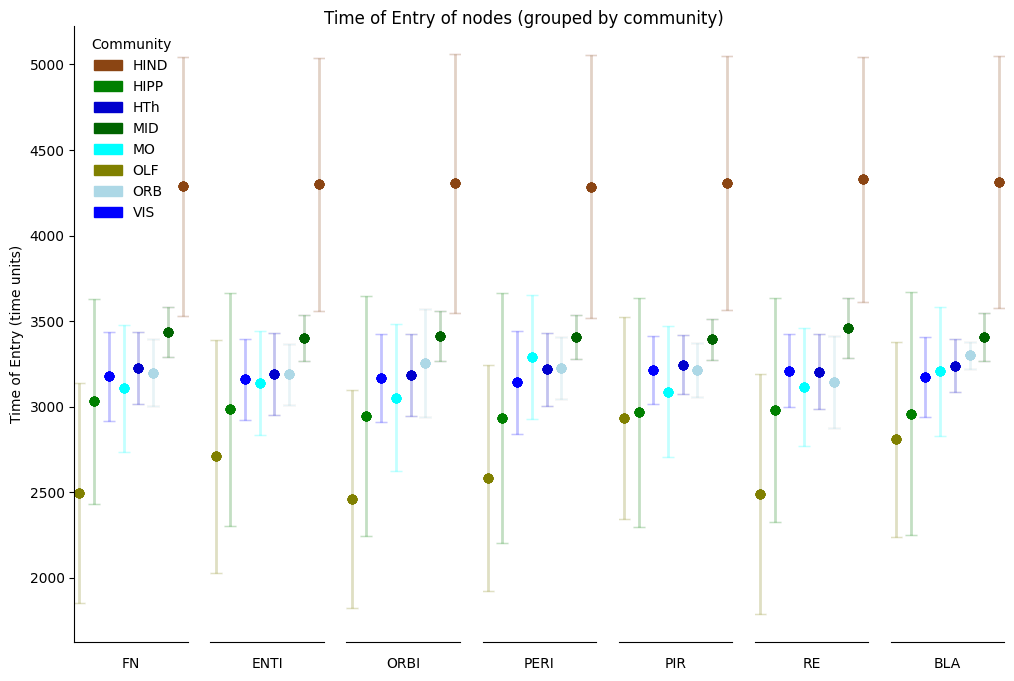

In [78]:
l = reader.get_communities()["comm_val"]
l = l.to_dict()
comm = ["MO", "VIS", "ORB", "HTh", "OLF", "HIPP", "MID", "HIND"]

node_c_avi = [
    "#00FFFF",
    "#0000FF",
    "#ADD8E6",
    "#0000CD",
    "#808000",
    "#008000",
    "#006400",
    "#8B4513",
]
colors = {
    "HIND": "#8B4513",
    "HIPP": "#008000",
    "HTh": "#0000CD",
    "MID": "#006400",
    "MO": "#00FFFF",
    "OLF": "#808000",
    "ORB": "#ADD8E6",
    "VIS": "#0000FF",
}
fig, ax = plt.subplots(1, 7, sharex=True, sharey=True, figsize=(12, 8))


node_c_nim = [
    "#FF0000",
    "#00FF00",
    "#0000FF",
    "#FFFF00",
    "#00FFFF",
    "#FF00FF",
    "#FFA500",
    "#800080",
]
col = dict(zip(comm, node_c_nim))
grouped = toe_plot_data.groupby("community")
for community, group in grouped:
    k = 0
    for idx, row in toe_stats["FN"].iterrows():

        # err = [[row['error_low']], [row['error_high']]]
        ax[0].errorbar(
            k,
            row["mean"],
            yerr=row["mad"],
            fmt="o",
            color=colors[idx],
            ecolor=mcolors.to_rgba(colors[idx], alpha=0.03),  # <- color by community
            elinewidth=2,
            capsize=4,
            label=idx,
        )
        k += 1

        ax[0].set_ylabel("Time of Entry (time units)")
        # ax[0].spines[["left", "right", "top", "bottom"]].set_visible(False)
        # ax[0].set_xticks([50])
        ax[0].set_xticklabels([])
        ax[0].set_xlabel("FN")
    # ax[0].tick_params(axis="both", which="both", length=0)

    k = 0
    for idx, row in toe_stats["ENTI"].iterrows():

        # err = [[row['error_low']], [row['error_high']]]
        ax[1].errorbar(
            k,
            row["mean"],
            yerr=row["mad"],
            fmt="o",
            color=colors[idx],
            ecolor=mcolors.to_rgba(colors[idx], alpha=0.03),  # <- color by community
            elinewidth=2,
            capsize=4,
        )
        k += 1

        # ax[0].spines[["left", "right", "top", "bottom"]].set_visible(False)
        # ax[0].set_xticks([50])

        # ax[1].set_xticks([50])
        ax[1].set_xticklabels([])
        ax[1].set_xlabel("ENTI")

    k = 0
    for idx, row in toe_stats["ORBI"].iterrows():

        # err = [[row['error_low']], [row['error_high']]]
        ax[2].errorbar(
            k,
            row["mean"],
            yerr=row["mad"],
            fmt="o",
            color=colors[idx],
            ecolor=mcolors.to_rgba(colors[idx], alpha=0.03),  # <- color by community
            elinewidth=2,
            capsize=4,
        )
        k += 1
        ax[2].set_xticklabels([])
        ax[2].set_xlabel("ORBI")

    k = 0
    for idx, row in toe_stats["PERI"].iterrows():

        # err = [[row['error_low']], [row['error_high']]]
        ax[3].errorbar(
            k,
            row["mean"],
            yerr=row["mad"],
            fmt="o",
            color=colors[idx],
            ecolor=mcolors.to_rgba(colors[idx], alpha=0.03),  # <- color by community
            elinewidth=2,
            capsize=4,
        )
        k += 1
        ax[3].set_xticklabels([])
        ax[3].set_xlabel("PERI")

    k = 0
    for idx, row in toe_stats["PIR"].iterrows():

        # err = [[row['error_low']], [row['error_high']]]
        ax[4].errorbar(
            k,
            row["mean"],
            yerr=row["mad"],
            fmt="o",
            color=colors[idx],
            ecolor=mcolors.to_rgba(colors[idx], alpha=0.03),  # <- color by community
            elinewidth=2,
            capsize=4,
        )
        k += 1
        ax[4].set_xticklabels([])
        ax[4].set_xlabel("PIR")

    k = 0
    for idx, row in toe_stats["RE"].iterrows():

        # err = [[row['error_low']], [row['error_high']]]
        ax[5].errorbar(
            k,
            row["mean"],
            yerr=row["mad"],
            fmt="o",
            color=colors[idx],
            ecolor=mcolors.to_rgba(colors[idx], alpha=0.03),  # <- color by community
            elinewidth=2,
            capsize=4,
        )
        k += 1
        ax[5].set_xticklabels([])
        ax[5].set_xlabel("RE")

    k = 0
    for idx, row in toe_stats["BLA"].iterrows():

        # err = [[row['error_low']], [row['error_high']]]
        ax[6].errorbar(
            k,
            row["mean"],
            yerr=row["mad"],
            fmt="o",
            color=colors[idx],
            ecolor=mcolors.to_rgba(colors[idx], alpha=0.03),  # <- color by community
            elinewidth=2,
            capsize=4,
        )
        k += 1
        ax[6].set_xticklabels([])
        ax[6].set_xlabel("BLA")

import matplotlib.patches as mpatches

# Assuming your 'colors' dictionary already exists
legend_elements = [
    mpatches.Patch(color=color, label=label) for label, color in colors.items()
]

ax[0].legend(
    handles=legend_elements,
    title="Community",
    loc="upper center",  # tweak as needed
    frameon=False,
)

# Remove outlines: Remove top/right spines from each subplot and hide most of the x-axis spines
for i, a in enumerate(ax):
    a.spines["top"].set_visible(False)
    a.spines["right"].set_visible(False)

    # Hide the bottom spine for all subplots except the first one:
    if i != 0:
        a.spines["bottom"].set_visible(False)
        a.tick_params(bottom=False)  # Remove tick marks on the x-axis
        a.spines["left"].set_visible(False)
        a.tick_params(left=False)
    else:
        a.spines["bottom"].set_visible(True)
        a.tick_params(bottom=True)

    # Ensure the left spine (y-axis) is visible:
    # a.spines['left'].set_visible(True)
    a.spines["bottom"].set_visible(True)
    a.tick_params(bottom=False)


# plt.legend()
plt.suptitle("Time of Entry of nodes (grouped by community)", x=0.5, y=0.9)
# plt.savefig('fig_3.png')
plt.show()

## Figure 4: Parameters for NOI (violin plots)

In [22]:
data_folder = Path("../../data/results/processed/")
files = glob.glob(str(data_folder / "itr*.bz2"))

tranPer_params = {}  # to store number of transitions
trans_params = {}  # to store transition times
sync_params = {}  # to store time spent in sync states
fpt_params = {}
cvr_params = {}
t_time = []
for f in files:
    # Extract the part of the filename after the underscore
    file_stem = Path(f).stem  # e.g., "itr_bla"
    name_suffix = file_stem.split("_")[1]  # e.g., "bla"
    df_d = pd.read_pickle(f, compression="bz2")
    df_d.columns = range(0, df_d.shape[1])

    # Compute parameters
    params = algo.compute_param_df(df_d)

    # Store lists in the dictionary
    tranPer_params[f"{name_suffix}"] = params["tran_per"]
    trans_params[f"{name_suffix}"] = params["trans"]
    # removing those which have sync state time zero
    sync = [i for i in params["sync"] if i != 0]
    sync_params[f"{name_suffix}"] = sync
    fpt_params[f"{name_suffix}"] = params["fpt"]
    cvr = [j for j in params["cov"] if j != 0 and not np.isnan(j)]
    cvr_params[f"{name_suffix}"] = cvr
    print(f"{f} DONE")

/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


start [34800]
35125


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainab

start [9500, 15500, 19500, 26900]
16135


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainab

...

10756
12684
18296
30102
start [8200, 27300, 33100]


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


9094
28464
33969
start [34100]


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainab

start [6800]
8330
../../data/results/processed/itr_re.bz2 DONE


In [23]:
params.keys()

dict_keys(['tran_per', 'sync', 'trans', 'fpt', 'cov'])

In [24]:
reader.data_dump_pkl("new_algo_param.pkl", params)

In [25]:
param_check = reader.data_read_pkl("new_algo_param.pkl")

## Stored parameter data

In [31]:
reader.data_dump_pkl("n_sync_state.pkl", sync_params)
reader.data_dump_pkl("n_trans_time.pkl", trans_params)
reader.data_dump_pkl("n_fpt.pkl", fpt_params)
reader.data_dump_pkl("n_transPer.pkl", tranPer_params)
reader.data_dump_pkl("n_cvr.pkl", cvr_params)

## Read stored data

In [6]:
sync_params = reader.data_read_pkl("n_sync_state.pkl")
trans_params = reader.data_read_pkl("n_trans_time.pkl")
tranPer_params = reader.data_read_pkl("n_transPer.pkl")
fpt_params = reader.data_read_pkl("n_fpt.pkl")
cvr_params = reader.data_read_pkl("n_cvr.pkl")

In [15]:
trans_params.keys()

dict_keys(['bla', 'enti', 'fn', 'orbi', 'peri', 'pir', 're'])

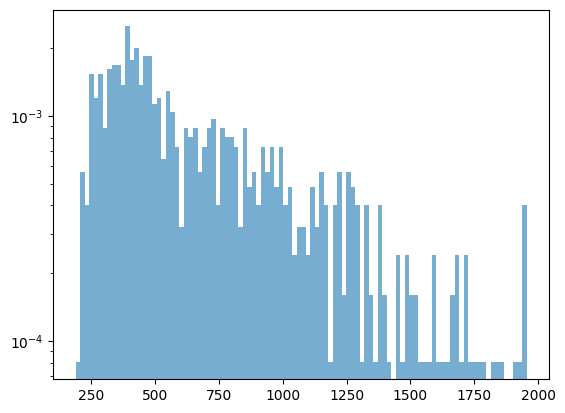

In [36]:
plt.figure()
# plt.hist(cvr_params['fn'],bins=100,alpha=0.6, density=True)
plt.hist(fpt_params["re"], bins=100, alpha=0.6, density=True)
plt.yscale("log")

In [33]:
print(
    np.std(trans_params["fn"]) / np.sqrt(len(trans_params["fn"])),
    np.mean(trans_params["fn"]),
)
np.std(cvr_params["re"]) / np.sqrt(len(cvr_params["re"])), np.mean(cvr_params["re"])

0.5467843743932821 63.5948275862069


(0.48735554247677393, 61.50679644808744)

In [28]:
scipy.stats.mannwhitneyu(trans_params["re"], trans_params["fn"])

MannwhitneyuResult(statistic=876494.5, pvalue=0.005346144521147316)

In [27]:
scipy.stats.ttest_ind(trans_params["re"], trans_params["fn"])

Ttest_indResult(statistic=-2.8587621750070635, pvalue=0.0042851326245333535)

In [7]:
node_order = np.array(["fn", "bla", "enti", "orbi", "peri", "pir", "re"])
non = np.r_[np.argsort([tranPer_params[k][-1] / 1000 for k in node_order[1:]]) + 1, 0]
non

array([1, 4, 5, 2, 3, 6, 0])

#### GEtting per 100 transitions

In [8]:
for key, value in tranPer_params.items():
    dum = np.array(value)
    value = list(np.diff(dum))
    tranPer_params[key] = value

print(tranPer_params)

{'bla': [80, 62, 71, 70, 62, 55, 79, 76, 81, 49], 'enti': [108, 93, 126, 134, 91, 106, 133, 103, 100, 129], 'fn': [132, 140, 132, 116, 111, 112, 175, 114, 118, 128], 'orbi': [120, 142, 108, 97, 131, 128, 97, 137, 115, 141], 'peri': [63, 83, 79, 76, 101, 75, 56, 85, 69, 95], 'pir': [91, 95, 90, 110, 110, 79, 100, 108, 107, 82], 're': [154, 139, 160, 160, 138, 151, 144, 149, 138, 137]}


## Man whitne U test to find if there is sinificant shift in median position

In [9]:
# simulate two distributions

cvr_node = []
group1 = np.asarray(cvr_params["fn"])
for k in node_order[non]:
    group2 = np.asarray(cvr_params[k])

    # two-sided Mann–Whitney
    U, p = mannwhitneyu(group1, group2, alternative="two-sided")
    if p < 0.05:
        cvr_node.append(k)
    print(f" Sync state: {k} Mann–Whitney U = {U:.1f}, p = {p:.3f}")

print(f"Significant node: {cvr_node}")

 Sync state: bla Mann–Whitney U = 161296.0, p = 0.031
 Sync state: peri Mann–Whitney U = 176650.0, p = 0.000
 Sync state: pir Mann–Whitney U = 200787.0, p = 0.043
 Sync state: enti Mann–Whitney U = 225412.0, p = 0.000
 Sync state: orbi Mann–Whitney U = 238687.0, p = 0.161
 Sync state: re Mann–Whitney U = 278484.0, p = 0.000
 Sync state: fn Mann–Whitney U = 242904.5, p = 1.000
Significant node: ['bla', 'peri', 'pir', 'enti', 're']


In [10]:
# simulate two distributions

sync_node = []
group1 = np.asarray(sync_params["fn"])
for k in node_order[non]:
    group2 = np.asarray(sync_params[k])

    # two-sided Mann–Whitney
    U, p = mannwhitneyu(group1, group2, alternative="two-sided")
    if p < 0.05:
        sync_node.append(k)
    print(f" Sync state: {k} Mann–Whitney U = {U:.1f}, p = {p:.3f}")

print(f"Significant node: {sync_node}")

 Sync state: bla Mann–Whitney U = 38006.0, p = 0.992
 Sync state: peri Mann–Whitney U = 43587.0, p = 0.206
 Sync state: pir Mann–Whitney U = 47010.5, p = 0.829
 Sync state: enti Mann–Whitney U = 56574.5, p = 0.728
 Sync state: orbi Mann–Whitney U = 55035.5, p = 0.927
 Sync state: re Mann–Whitney U = 66698.0, p = 0.711
 Sync state: fn Mann–Whitney U = 57122.0, p = 1.000
Significant node: []


In [11]:
trans_node = []
group1 = np.asarray(trans_params["fn"])
for k in node_order[non]:
    group2 = np.asarray(trans_params[k])

    # two-sided Mann–Whitney
    U, p = mannwhitneyu(group1, group2, alternative="two-sided")
    if p < 0.05:
        trans_node.append(k)
    print(f" Duration: {k} Mann–Whitney U = {U:.1f}, p = {p:.3f}")

print(f"Significant node: {trans_node}")

 Duration: bla Mann–Whitney U = 408813.5, p = 0.027
 Duration: peri Mann–Whitney U = 528219.0, p = 0.019
 Duration: pir Mann–Whitney U = 634659.5, p = 0.434
 Duration: enti Mann–Whitney U = 797628.0, p = 0.000
 Duration: orbi Mann–Whitney U = 785391.5, p = 0.475
 Duration: re Mann–Whitney U = 991569.5, p = 0.005
 Duration: fn Mann–Whitney U = 814088.0, p = 1.000
Significant node: ['bla', 'peri', 'enti', 're']


In [12]:
tranPer_node = []
group1 = np.asarray(tranPer_params["fn"])
for k in node_order[non]:
    group2 = np.asarray(tranPer_params[k])

    # two-sided Mann–Whitney
    U, p = mannwhitneyu(group1, group2, alternative="two-sided", method="exact")
    if p < 0.05:

        tranPer_node.append(k)
    print(f" #transition: {k} Mann–Whitney U = {U:.1f}, p = {p:.3f}")
print(f"Significant node: {tranPer_node}")

 #transition: bla Mann–Whitney U = 100.0, p = 0.000
 #transition: peri Mann–Whitney U = 100.0, p = 0.000
 #transition: pir Mann–Whitney U = 100.0, p = 0.000
 #transition: enti Mann–Whitney U = 73.0, p = 0.089
 #transition: orbi Mann–Whitney U = 54.5, p = 0.796
 #transition: re Mann–Whitney U = 14.0, p = 0.005
 #transition: fn Mann–Whitney U = 50.0, p = 1.000
Significant node: ['bla', 'peri', 'pir', 're']


In [13]:
fpt_node = []
group1 = np.asarray(fpt_params["fn"])
for k in node_order[non]:
    group2 = np.asarray(fpt_params[k])

    # two-sided Mann–Whitney
    U, p = mannwhitneyu(group1, group2, alternative="two-sided")
    if p < 0.05:
        fpt_node.append(k)
    print(f" FPT: {k} Mann–Whitney U = {U:.1f}, p = {p:.3f}")

print(f"Significant node: {fpt_node}")

 FPT: bla Mann–Whitney U = 120613.5, p = 0.000
 FPT: peri Mann–Whitney U = 124427.5, p = 0.000
 FPT: pir Mann–Whitney U = 168573.5, p = 0.000
 FPT: enti Mann–Whitney U = 163811.0, p = 0.000
 FPT: orbi Mann–Whitney U = 229082.0, p = 0.581
 FPT: re Mann–Whitney U = 252453.0, p = 0.453
 FPT: fn Mann–Whitney U = 245000.0, p = 1.000
Significant node: ['bla', 'peri', 'pir', 'enti']


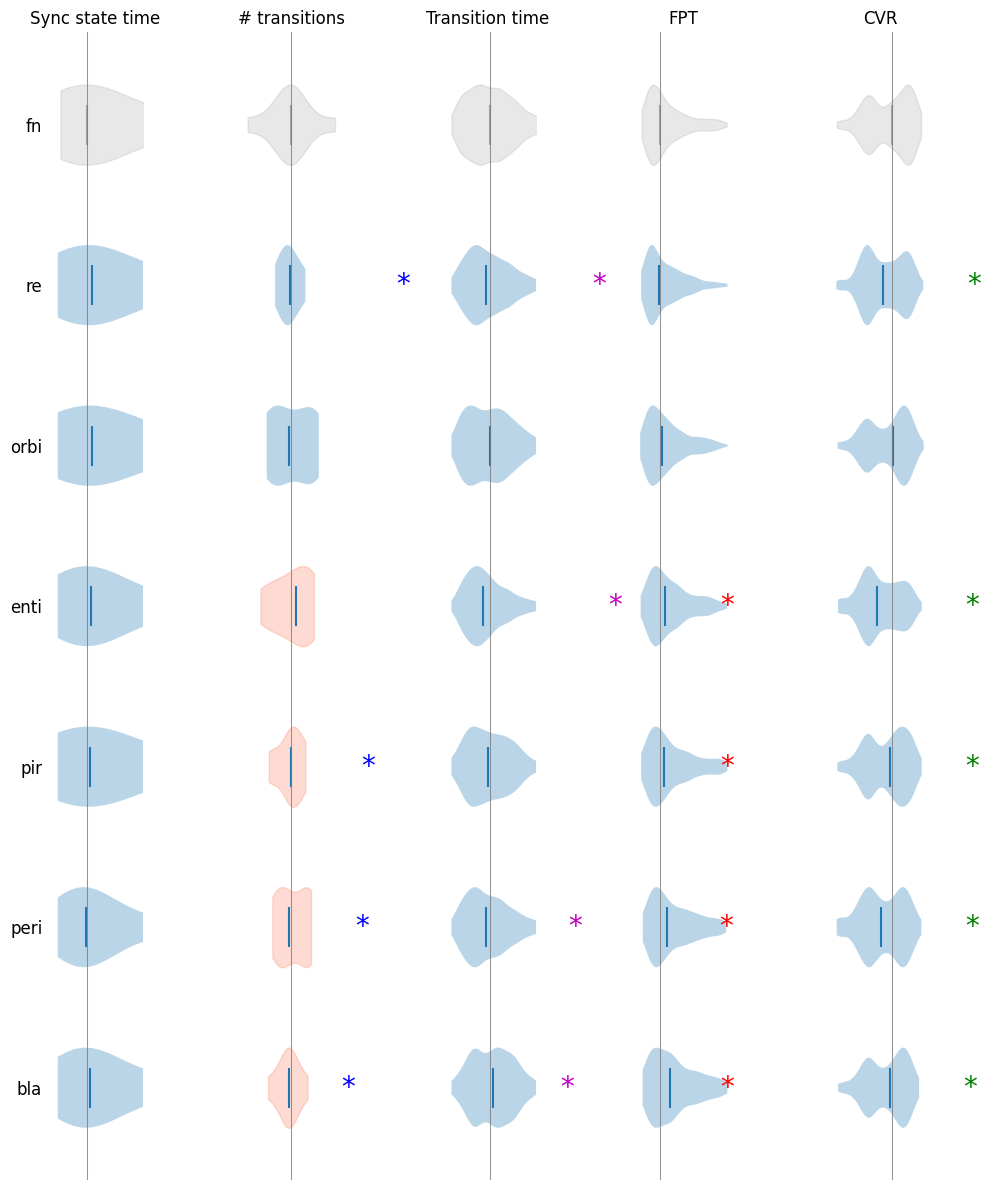

In [14]:
f, (ax1, ax2, ax3, ax4, ax5) = plt.subplots(1, 5, figsize=(10, 12), sharey=True)

# ccoverage
_artists = ax5.violinplot(
    [cvr_params[k] for k in node_order[non]],
    vert=False,
    showextrema=False,
    showmedians=True,
)
# ax4.set_yticks(np.arange(1, len(fpt_node) + 1))
# ax4.set_yticklabels(['*']*len(fpt_node), fontsize=30)

_artists["bodies"][-1].set_color(cm.Greys(0.4, 0.4))
_artists["cmedians"].set_color(
    list(_artists["cmedians"].get_color()) * 6 + [cm.Greys(0.8, 0.4)]
)
ax5.spines[["left", "right", "top", "bottom"]].set_visible(False)
ax5.set_xticks([])
# ax3.set_xlim(20, 100)
ax5.tick_params(axis="both", which="both", length=0)
ax5.set_title("CVR")
ax5.axvline(np.median(cvr_params["fn"]), c=cm.Greys(0.6, 0.8), lw=0.75)


offset = 0.3  # how far to the right of the violin you want the asterisk
for idx, node in enumerate(node_order[non], start=1):
    if node in cvr_node:
        # pick a y‐pos = idx, x‐pos = e.g. max of that group + offset
        x = np.max(cvr_params[node]) + offset
        y = idx
        ax5.text(x, y, "*", ha="center", va="center", color="green", fontsize=20)


# First passage time
_artists = ax4.violinplot(
    [fpt_params[k] for k in node_order[non]],
    vert=False,
    showextrema=False,
    showmedians=True,
)
# ax4.set_yticks(np.arange(1, len(fpt_node) + 1))
# ax4.set_yticklabels(['*']*len(fpt_node), fontsize=30)

_artists["bodies"][-1].set_color(cm.Greys(0.4, 0.4))
_artists["cmedians"].set_color(
    list(_artists["cmedians"].get_color()) * 6 + [cm.Greys(0.8, 0.4)]
)
ax4.spines[["left", "right", "top", "bottom"]].set_visible(False)
ax4.set_xticks([])
# ax3.set_xlim(20, 100)
ax4.tick_params(axis="both", which="both", length=0)
ax4.set_title("FPT")
ax4.axvline(np.median(fpt_params["fn"]), c=cm.Greys(0.6, 0.8), lw=0.75)


offset = 0.3  # how far to the right of the violin you want the asterisk
for idx, node in enumerate(node_order[non], start=1):
    if node in fpt_node:
        # pick a y‐pos = idx, x‐pos = e.g. max of that group + offset
        x = np.max(fpt_params[node]) + offset
        y = idx
        ax4.text(x, y, "*", ha="center", va="center", color="red", fontsize=20)


# # number of transitions
_artists = ax3.violinplot(
    [trans_params[k] for k in node_order[non]],
    vert=False,
    showextrema=False,
    showmedians=True,
)
# ax3.set_yticks(np.arange(1, len(node_order) + 1))
# ax3.set_yticklabels(node_order[non], fontsize=12)
_artists["bodies"][-1].set_color(cm.Greys(0.4, 0.4))
_artists["cmedians"].set_color(
    list(_artists["cmedians"].get_color()) * 6 + [cm.Greys(0.8, 0.4)]
)
ax3.spines[["left", "right", "top", "bottom"]].set_visible(False)
ax3.set_xticks([])
ax3.set_xlim(20, 100)
ax3.tick_params(axis="both", which="both", length=0)
ax3.set_title("Transition time")
ax3.axvline(np.median(trans_params["fn"]), c=cm.Greys(0.6, 0.8), lw=0.75)

offset = 0.05  # how far to the right of the violin you want the asterisk
for idx, node in enumerate(node_order[non], start=1):
    if node in trans_node:
        # pick a y‐pos = idx, x‐pos = e.g. max of that group + offset
        x = np.max(trans_params[node]) + offset
        y = idx
        ax3.text(x, y, "*", ha="center", va="center", color="m", fontsize=20)


# sync state
_artists = ax1.violinplot(
    [sync_params[k] for k in node_order[non]],
    vert=False,
    showextrema=False,
    showmedians=True,
)
ax1.set_yticks(np.arange(1, len(node_order) + 1))
ax1.set_yticklabels(node_order[non], fontsize=12)
_artists["bodies"][-1].set_color(cm.Greys(0.4, 0.4))
_artists["cmedians"].set_color(
    list(_artists["cmedians"].get_color()) * 6 + [cm.Greys(0.8, 0.4)]
)
ax1.spines[["left", "right", "top", "bottom"]].set_visible(False)
ax1.set_xticks([])
ax1.set_xlim(20, 200)
ax1.tick_params(axis="both", which="both", length=0)
ax1.set_title("Sync state time")
ax1.axvline(np.median(sync_params["fn"]), c=cm.Greys(0.6, 0.8), lw=0.75)

offset = 0.01  # how far to the right of the violin you want the asterisk
for idx, node in enumerate(node_order[non], start=1):
    if node in sync_node:
        # pick a y‐pos = idx, x‐pos = e.g. max of that group + offset
        x = np.max(sync_params[node]) + offset
        y = idx
        ax1.text(x, y, "*", ha="center", va="center", color="red", fontsize=20)


# number of transitions
_artists = ax2.violinplot(
    [np.diff(np.array(tranPer_params[k])) for k in node_order[non]],
    vert=False,
    showextrema=False,
    showmedians=True,
)
# ax3.set_yticks(np.arange(1, len(node_order)+1))
# ax3.set_yticklabels(node_order)
_artists["bodies"][-1].set_color(cm.Greys(0.4, 0.4))
for i in range(4):
    _artists["bodies"][i].set_color(cm.Reds(0.4, 0.4))
_artists["cmedians"].set_color(
    list(_artists["cmedians"].get_color()) * 6 + [cm.Greys(0.8, 0.4)]
)
ax2.spines[["left", "right", "top", "bottom"]].set_visible(False)
ax2.set_xticks([])
# ax3.set_xlim(80, 500)
ax2.tick_params(axis="both", which="both", length=0)
ax2.set_title("# transitions")
ax2.axvline(np.median(np.diff(tranPer_params["fn"])), c=cm.Greys(0.6, 0.8), lw=0.75)

offset = 0.01  # how far to the right of the violin you want the asterisk
for idx, node in enumerate(node_order[non], start=1):
    if node in tranPer_node:
        # pick a y‐pos = idx, x‐pos = e.g. max of that group + offset
        x = np.max(tranPer_params[node]) + offset
        y = idx
        ax2.text(x, y, "*", ha="center", va="center", color="blue", fontsize=20)

f.subplots_adjust(wspace=0.8)
f.tight_layout()
f.savefig("cntrl_param_violin.png")

# Reading data for control nodes and plotting violin plots with MU test

In [52]:
# read data of control nodes
data_folder = Path("../../data/raw/check_control/")
# control_nc=glob.glob(str(data_folder / "nc_200*.bz2"))
control_itr = glob.glob(str(data_folder / "itr_200*.bz2"))

tranPer_params = {}  # to store number of transitions
trans_params = {}  # to store transition times
sync_params = {}  # to store time spent in sync states
fpt_params = {}
cvr_params = {}
t_time = []
for f in control_itr:
    # Extract the part of the filename after the underscore
    file_stem = Path(f).stem  # e.g., "itr_bla"
    name_suffix = file_stem.split("_")[2]  # e.g., "bla"
    df_d = pd.read_pickle(f, compression="bz2")
    df_d.columns = range(0, df_d.shape[1])

    # Compute parameters
    params = algo.compute_param_df(df_d)

    # Store lists in the dictionary
    tranPer_params[f"{name_suffix}"] = params["tran_per"]
    trans_params[f"{name_suffix}"] = params["trans"]
    # removing those which have sync state time zero
    sync = [i for i in params["sync"] if i != 0]
    sync_params[f"{name_suffix}"] = sync
    fpt_params[f"{name_suffix}"] = params["fpt"]
    cvr = [j for j in params["cov"] if j != 0 and not np.isnan(j)]
    cvr_params[f"{name_suffix}"] = cvr
    print(f"{f} DONE")

/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


start [7500, 11500, 15300, 21000, 26500, 30800]
8851
12836
16288
27676
31787
start [13200]


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


13825
start [7800]


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

16313
start [6400, 11700, 14100]


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


12086
15282


/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/home/jupyter-nimish/env_tes/lib/python3.10/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainab

start [10000, 15500, 35600]
10949
16456
36669
../../data/raw/check_control/itr_200_fn.bz2 DONE


In [53]:
reader.data_dump_pkl("results/control_200_itr/n_sync_state.pkl", sync_params)
reader.data_dump_pkl("results/control_200_itr/n_trans_time.pkl", trans_params)
reader.data_dump_pkl("results/control_200_itr/n_fpt.pkl", fpt_params)
reader.data_dump_pkl("results/control_200_itr/n_transPer.pkl", tranPer_params)
reader.data_dump_pkl("results/control_200_itr/n_cvr.pkl", cvr_params)

In [64]:
sync_params = reader.data_read_pkl("results/control_200_itr/n_sync_state.pkl")
trans_params = reader.data_read_pkl("results/control_200_itr/n_trans_time.pkl")
fpt_params = reader.data_read_pkl("results/control_200_itr/n_fpt.pkl")
tranPer_params = reader.data_read_pkl("results/control_200_itr/n_transPer.pkl")
cvr_params = reader.data_read_pkl("results/control_200_itr/n_cvr.pkl")

In [65]:
node_order = np.array(["fn", "1", "2", "3", "4"])

non = np.r_[np.argsort([tranPer_params[k][-1] / 1000 for k in node_order[1:]]) + 1, 0]

non

array([1, 3, 4, 2, 0])

In [56]:
for key, value in tranPer_params.items():
    dum = np.array(value)
    value = list(np.diff(dum))
    tranPer_params[key] = value

print(tranPer_params)

{'1': [102, 97], '2': [126, 148], '3': [109, 127], '4': [135, 113], 'fn': [134, 164]}
